# Forecasting III
# Autoregressive, Moving Average, and ARIMA Models

This workbook is part of a series, listed below:
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Forecasting%20I%20-%20Baseline%20Methods.ipynb">Forecasting I - Baseline Methods</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Forecasting%20II%20-%20Exponential%20Smoothing.ipynb">Forecasting II - Exponential Smoothing</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Forecasting%20III%20-%20Autoregressive%20Models.ipynb">Forecasting III - Autoregressive Models</a>

### Autoregressive AR(p) Models

In an autoregressive AR(p) model, we forecast the variable of interest using a linear combination of time-lags. Like the coefficients of an ACF plot can be used to describe the order of a moving average (MA) process (discussed next), the coefficients on a partial autocorrelation function (PACF) plot become abruptly insignificant after lag p in an AR model.

$$y_{t} = c + \phi_{1}y_{t-1} + \phi_{2}y_{t-2} + \dots + \phi_{p}y_{t-p} + \varepsilon_{t}$$

### Moving Average MA(q) Models

Unlike 'simple moving average' models, which average a certain number of recent time points, moving average (MA) models consider <i>the error</i> of prior forecasts. An MA model is to order q, the number of lags before the autocorrelation drops to insignificance. The MA(q) model does not allow predictions far into the future; error terms being unavailable for a long range forecast will result in recursive estimation.

$$y_{t} = c + \varepsilon_t + \theta_{1}\varepsilon_{t-1} + \theta_{2}\varepsilon_{t-2} + \dots + \theta_{q}\varepsilon_{t-q}$$

### ARMA(p,q) Models

Combine an AR(p) model with an MA(q) model, and you have what is referred to as an ARMA model.

$$\begin{equation}y'_{t} = c + \phi_{1}y'_{t-1} + \cdots + \phi_{p}y'_{t-p}+ \theta_{1}\varepsilon_{t-1} + \cdots + \theta_{q}\varepsilon_{t-q} + \varepsilon_{t},  \end{equation}$$

You might be asking, why no code yet? Well, just as AR and MA parameters can be considered in the same model, there is an additional parameter, integration (meaning degree of differencing), which gets incorporated into an ARIMA (Autoregressive Integrated Moving Average) model, and from a coding perspective, we can just search the parameters of the ARIMA model and let that tell us whether it is purely autoregressive or moving average oriented.

### ARIMA(p,d,q) Models

The order of differencing in an ARIMA model is represented by the d in (p,d,q). Selecting d involves stationarity testing, and there are a variety of tests one may use. There are auto-ARIMA algorithms by which one thoroughly loops through a grid of potential values for parameters.

ARIMA is a non-seasonal method, which is why we have SARIMA, discussed further below.

# Import Libraries and Data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')
import statsmodels.api as sm
import scipy
from tqdm import tqdm

# Pulling Financial Data

We'll select two datasets from the US Federal Reserve Economic Database; one seasonal and one non-seasonal. For a list of data available from FRED through NasdaqLink, see: https://data.nasdaq.com/data/FRED-federal-reserve-economic-data

First, we install the nasdaqdatalink package if it is not installed already.

In [2]:
# !pip install --user Nasdaq-Data-Link

Then, import the necessary module.

In [3]:
import nasdaqdatalink

To make more than 50 calls to the database per day requires an API key, generated upon free sign-up at: https://data.nasdaq.com/sign-up. You can save it to the api_key variable to use it, as below.

In [4]:
nasdaqdatalink.ApiConfig.api_key = "4xJoCvA6Ws7KXkQVw9ip"

### Consumer Price Index Data

This represents the index of a weighted average market basket of consumer goods and services compared to the pricing of a reference year, and captured on an annual basis.

In [5]:
cpi = nasdaqdatalink.get("FRED/FPCPITOTLZGUSA", start_date="1965-01-01")
cpi = cpi[cpi['Value'] > 0]

### Seasonal Borrowing Data

The Federal Reserve's seasonal credit program is designed to assist small depository institutions in managing significant seasonal swings in their loans and deposits. Seasonal credit is available to depository institutions that can demonstrate a clear pattern of recurring intra-yearly swings in funding needs. Eligible institutions are usually located in agricultural or tourist areas.

In [6]:
sborrow = nasdaqdatalink.get("FRED/SEABORRW", start_date="2015-01-01")
sborrow = sborrow[sborrow.index.weekofyear < 53]

# Error Metrics

In [7]:
from sklearn.metrics import mean_absolute_error

def rmse(actual, pred):
    return np.sqrt(np.mean((actual - pred)**2))

# Walkforward Validation

In [10]:
def create_schedule(dataset, field, n_train):
    X = dataset[field].values
    n_records = len(X)
    
    train_st = []
    train_end = []
    test_st = []
    test_end = []
    
    for i in range(0, int(n_records/n_train-1)):
        train_st.append(i*n_train)
        train_end.append(i*n_train+n_train-1)
        test_st.append(train_end[-1]+1)
        test_end.append(test_st[i]+n_train-1)
        
        schedule = pd.DataFrame(columns=['train_st', 'train_end', 'test_st', 'test_end'])
        schedule['train_st'] = train_st
        schedule['train_end'] = train_end
        schedule['test_st'] = test_st
        schedule['test_end'] = test_end
        
        schedule['RMSE'] = np.NaN
        schedule['MAE'] = np.NaN
        
    return schedule

# ARIMA

In [11]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

In [12]:
arima_df = pd.DataFrame(columns = ('p', 'd', 'q', 'RMSE', 'MAE'))

def append_arima_results(p, d, q, rmse, mae):
    new_rownum = len(arima_df) + 1
    arima_df.loc[new_rownum,'p'] = p
    arima_df.loc[new_rownum,'d'] = d
    arima_df.loc[new_rownum,'q'] = q
    arima_df.loc[new_rownum,'RMSE'] = round(rmse,2)
    arima_df.loc[new_rownum,'MAE'] = round(mae,2)

In [13]:
def arima_predict(ps,ds,qs):
    for p in tqdm(ps):
        for d in ds:
            for q in qs:
                schedule = create_schedule(dataset, field, n_train)

                for i in range(0,len(schedule)):
                    train_st_idx = schedule['train_st'][i]
                    train_end_idx = schedule['train_end'][i]
                    test_st_idx = schedule['test_st'][i]
                    test_end_idx = schedule['test_end'][i]

                    model = ARIMA(dataset[field][train_st_idx:train_end_idx], order=(p,d,q))      
                    result = model.fit()
                    yhat = result.predict(test_st_idx,test_st_idx+n_train-1)
                    yhat[yhat<0] = 0
                    
                    actuals = dataset[field][test_st_idx:test_end_idx+1].values
                    actuals = actuals[-n_train:]
                    rmse_result = rmse(yhat.values, actuals)
                    mae_result = mean_absolute_error(yhat.values, actuals)
                    schedule['RMSE'] = rmse_result
                    schedule['MAE'] = mae_result
                    
            rmse_result = schedule['RMSE'].mean()
            mae_result = schedule['MAE'].mean()
            append_arima_results(p,d,q,round(rmse_result,3),round(mae_result,3))

In [14]:
dataset = cpi
field = 'Value'
n_train = 10

ps = [0,1,2,3,4,5]
ds = [0,1,2,3,4]
qs = [0,1,2,3,4,5]

arima_predict(ps,ds,qs)

100%|██████████| 6/6 [06:29<00:00, 64.89s/it]


In [15]:
arima_df.sort_values(by=['RMSE', 'MAE'], ascending=True).head()

,p,d,q,RMSE,MAE
3,0,2,5,1.08,0.94
27,5,1,5,1.08,0.97
21,4,0,5,1.08,0.98
22,4,1,5,1.08,0.98
11,2,0,5,1.09,0.95


# SARIMA(p,d,q)(P,D,Q,s) Models

SARIMA, 'Seasonal ARIMA', doubles up on the (p,d,q) terms, but with a capitalized set that applies to the data upon seasonal cycles, though in the same fashion as how the lower case (p,d,q) terms are applied to the ARIMA portion of the model. Also introduced is a parameter s, representing the season period length, and responsible for the seasonality. P is the order of autoregression upon the seasonal component of the model, D is the order of seasonal integration (differencing), and Q has similar logic to P, but is found using the ACF instead of the PACF.

I'll use an auto-ARIMA implementation to do a stepwise search of parameters, and do a walkforward validation with the best model found.

In [16]:
import pmdarima as pm

In [19]:
def train_test_split(data, n_test):
    return data[:-n_test], data[-n_test:]

In [20]:
sborrow_train, sborrow_test = train_test_split(sborrow['Value'].values, 104)

In [23]:
model = pm.auto_arima(sborrow_train,
                      trace=True,
                      suppress_warnings=True,
                      seasonal=True, 
                      m=52)

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(1,0,1)[52] intercept   : AIC=1564.897, Time=3.38 sec
 ARIMA(0,0,0)(0,0,0)[52] intercept   : AIC=2237.698, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[52] intercept   : AIC=1599.381, Time=1.96 sec
 ARIMA(0,0,1)(0,0,1)[52] intercept   : AIC=2101.141, Time=1.73 sec
 ARIMA(0,0,0)(0,0,0)[52]             : AIC=2394.692, Time=0.01 sec
 ARIMA(2,0,2)(0,0,1)[52] intercept   : AIC=1572.106, Time=3.06 sec
 ARIMA(2,0,2)(1,0,0)[52] intercept   : AIC=1567.092, Time=3.79 sec
 ARIMA(2,0,2)(2,0,1)[52] intercept   : AIC=1569.856, Time=113.11 sec
 ARIMA(2,0,2)(1,0,2)[52] intercept   : AIC=1568.140, Time=67.42 sec
 ARIMA(2,0,2)(0,0,0)[52] intercept   : AIC=1587.342, Time=0.13 sec
 ARIMA(2,0,2)(0,0,2)[52] intercept   : AIC=1571.569, Time=49.40 sec
 ARIMA(2,0,2)(2,0,0)[52] intercept   : AIC=1570.329, Time=67.72 sec
 ARIMA(2,0,2)(2,0,2)[52] intercept   : AIC=1569.477, Time=64.32 sec
 ARIMA(1,0,2)(1,0,1)[52] intercept   : AIC=inf, Time=2.72 sec
 ARIMA(2,0,1)(1,0,

The best model found by the search is of order (3,0,2)(0,0,1,52)

In [24]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [28]:
def sarima_predict(dataset, field, n_train):
    
    schedule = create_schedule(dataset, field, n_train)

    for i in range(0,len(schedule)):
        train_st_idx = schedule['train_st'][i]
        train_end_idx = schedule['train_end'][i]
        test_st_idx = schedule['test_st'][i]
        test_end_idx = schedule['test_end'][i]

        model = SARIMAX(dataset[field][train_st_idx:train_end_idx], order=(3,0,2), s_order=(0,0,1,52))      
        result = model.fit()
        yhat = result.predict(test_st_idx,test_st_idx+n_train-1)
        yhat[yhat<0] = 0

        actuals = dataset[field][test_st_idx:test_end_idx+1].values
        actuals = actuals[-n_train:]
        rmse_result = rmse(yhat.values, actuals)
        mae_result = mean_absolute_error(yhat.values, actuals)
        schedule['RMSE'] = rmse_result
        schedule['MAE'] = mae_result

    rmse_result = schedule['RMSE'].mean()
    mae_result = schedule['MAE'].mean()
    return rmse_result, mae_result

In [38]:
rmse_result, mae_result = sarima_predict(sborrow, 'Value', 52*2)
print('RMSE: ' + str(rmse_result) + ', MAE: ' + str(mae_result))

RMSE: 127.95615583020191, MAE: 95.87898097136488


# Multi-Step Prediction

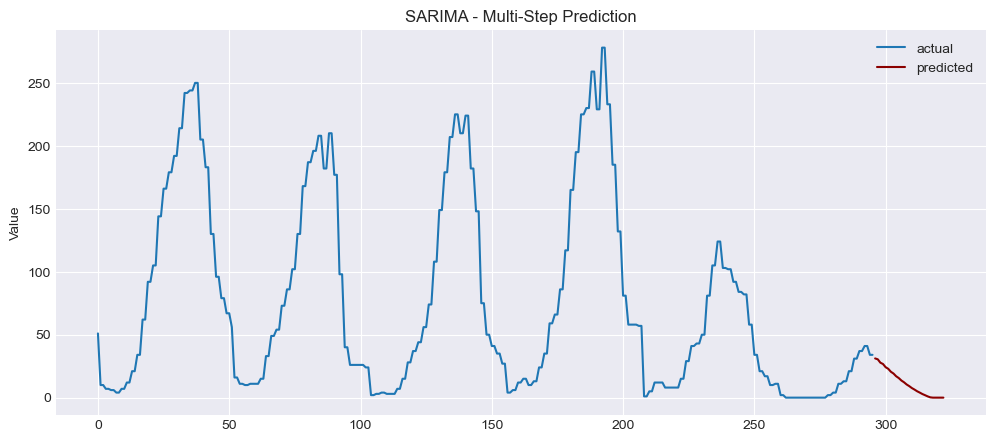

In [45]:
model = SARIMAX(sborrow['Value'], order=(3,0,2), s_order=(0,0,1,52))        

result = model.fit(optimized=True)
actuals = sborrow['Value'].values
predictions = result.predict(len(sborrow), len(sborrow)+26)
predictions[predictions < 0] = 0

plt.figure(figsize=(12,5))
plt.plot(actuals, label='actual')
plt.plot(predictions, 'darkred', label='predicted')
plt.title('SARIMA - Multi-Step Prediction')
plt.ylabel('Value')
plt.legend()
plt.show();